# Silkscan Pipeline Demo

In [1]:
import os, sys, cv2
sys.path.append(os.path.abspath('.'))
import silkscan_proto, open3d as o3d, numpy as np, matplotlib.pyplot as plt
from tqdm import tqdm
from scipy.ndimage import uniform_filter1d
%matplotlib inline

## 1. Load Capture Set

In [2]:
capture_set = silkscan_proto.load_capture_set('../scans/tangle016')
print(f'Loaded {capture_set.name} with {len(capture_set.sweeps)} sweeps.')

Loaded tangle016 with 3 sweeps.


## 3. Configure Pipeline

In [3]:
config_steger = silkscan_proto.Config(
    method='steger', intensity_threshold=0.05, strength_threshold=0.002,
    high_intensity_threshold=0.15, high_strength_threshold=0.015,
    sigma=0.5, persistence_min_frames=5, temporal_spatial_radius=2.0,
    spatial_2d_min_length_px=20, temporal_stack_frames=5,
    dedup_radius_mm=0.5, icp_voxel_size=2.0, icp_distance_threshold=5.0,
    box_crop_padding_px=25)
config_thresh = silkscan_proto.Config(
    method='threshold', intensity_threshold=0.15,
    persistence_min_frames=5, temporal_spatial_radius=2.0,
    dedup_radius_mm=0.5, icp_voxel_size=2.0, icp_distance_threshold=5.0,
    box_crop_padding_px=25)
output_dir = '../scans/tangle016'
os.makedirs(output_dir, exist_ok=True)

## 3.7 Temporal Sum & Rotated Quad Detection

Brightness and sum images are **cached** in `output_dir/.cache/`. Delete the `.cache` dir to recompute.

Row 1: Per-frame brightness → box-active range.
Row 2: Sum of box-active frames.
Row 3: Rotation angle search.
Row 4: Projection profiles at best angle.
Row 5: Detected rotated quad vs manifest.

  [CACHED] Loading brightness for sweep1
  Box-active: frames 1190-5525 (77%)
  [CACHED] Loading sum image for sweep1
  Detecting quad for sweep1...
  Best angle: -1.2deg (sharpness=2168)
  Rotated rect: x=[662,1528], y=[152,989]
  [CACHED] Loading brightness for sweep2
  Box-active: frames 1160-5500 (77%)
  [CACHED] Loading sum image for sweep2
  Detecting quad for sweep2...
  Best angle: -1.1deg (sharpness=3550)
  Rotated rect: x=[660,1497], y=[152,989]
  [CACHED] Loading brightness for sweep3
  Box-active: frames 1085-5455 (78%)
  [CACHED] Loading sum image for sweep3
  Detecting quad for sweep3...
  Best angle: -0.9deg (sharpness=4038)
  Rotated rect: x=[664,1535], y=[136,987]


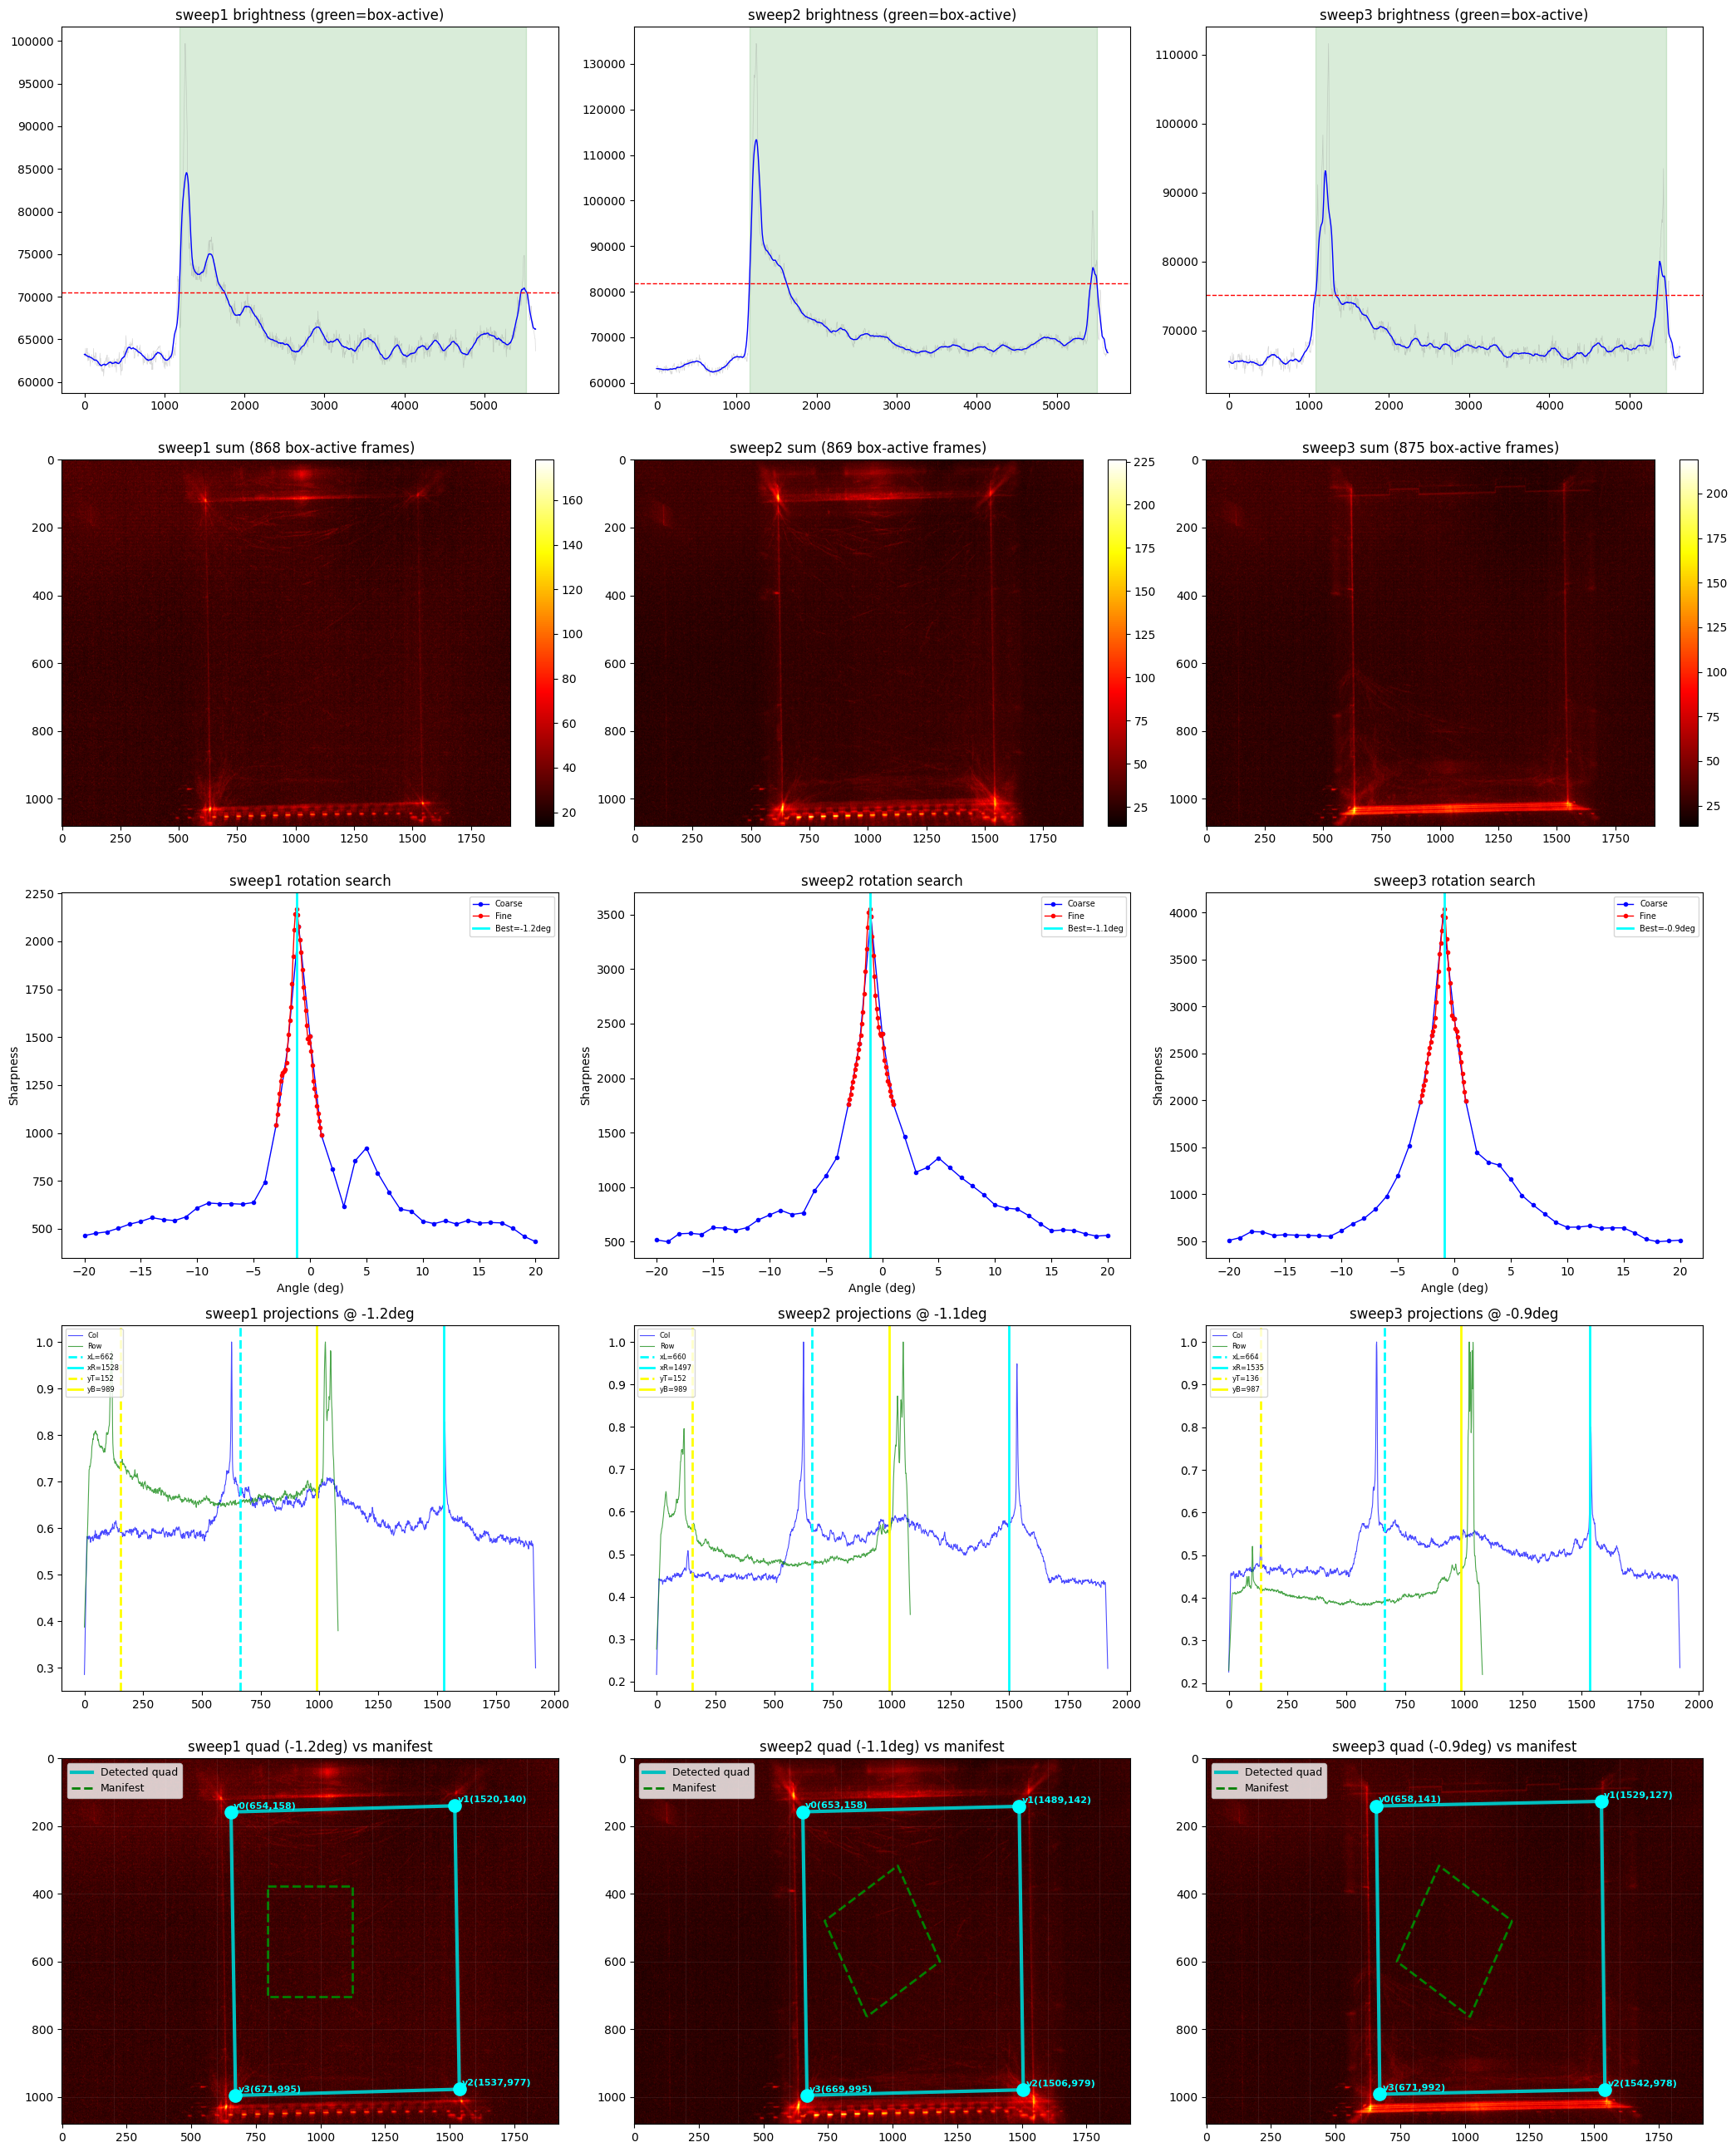


=== Detected Quad Vertices ===
sweep1: [[653, 158], [1519, 140], [1537, 977], [671, 995]]
sweep2: [[652, 157], [1489, 141], [1505, 978], [668, 994]]
sweep3: [[657, 140], [1528, 127], [1541, 977], [671, 991]]


In [4]:
def detect_quad_rotated(accum):
    h_img, w_img = accum.shape
    cx, cy = w_img / 2.0, h_img / 2.0
    ks = 31
    margin_frac = 0.05
    def score_angle(angle_deg):
        M = cv2.getRotationMatrix2D((cx, cy), angle_deg, 1.0)
        rotated = cv2.warpAffine(accum.astype(np.float32), M, (w_img, h_img))
        col_proj = rotated.sum(axis=0)
        row_proj = rotated.sum(axis=1)
        col_s = uniform_filter1d(col_proj, size=ks)
        row_s = uniform_filter1d(row_proj, size=ks)
        col_g = np.gradient(col_s)
        row_g = np.gradient(row_s)
        mx = int(w_img * margin_frac); my = int(h_img * margin_frac)
        col_g[:mx] = 0; col_g[-mx:] = 0
        row_g[:my] = 0; row_g[-my:] = 0
        # Find separated peaks: after strongest, suppress neighborhood before finding 2nd
        min_sep_x = int(w_img * 0.2)
        min_sep_y = int(h_img * 0.2)
        p1x = np.argmax(np.abs(col_g))
        col_g2 = col_g.copy()
        col_g2[max(0,p1x-min_sep_x):min(len(col_g2),p1x+min_sep_x)] = 0
        p2x = np.argmax(np.abs(col_g2))
        xl, xr = min(p1x, p2x), max(p1x, p2x)
        p1y = np.argmax(np.abs(row_g))
        row_g2 = row_g.copy()
        row_g2[max(0,p1y-min_sep_y):min(len(row_g2),p1y+min_sep_y)] = 0
        p2y = np.argmax(np.abs(row_g2))
        yt, yb = min(p1y, p2y), max(p1y, p2y)
        sharpness = abs(col_g[p1x]) + abs(col_g2[p2x]) + abs(row_g[p1y]) + abs(row_g2[p2y])
        return sharpness, xl, xr, yt, yb, col_proj, row_proj, col_g, row_g
    angles = np.arange(-20, 21, 1.0)
    scores = np.array([score_angle(a)[0] for a in angles])
    best_coarse = angles[np.argmax(scores)]
    fine_angles = np.arange(best_coarse - 2, best_coarse + 2.1, 0.1)
    fine_scores = np.array([score_angle(a)[0] for a in fine_angles])
    best_angle = fine_angles[np.argmax(fine_scores)]
    _, xl, xr, yt, yb, col_proj, row_proj, col_g, row_g = score_angle(best_angle)
    # Apply padding (inset by 20px to avoid box walls)
    pad = 20
    xl += pad; xr -= pad; yt += pad; yb -= pad
    print(f'  Best angle: {best_angle:.1f}deg (sharpness={fine_scores.max():.0f})')
    print(f'  Rotated rect: x=[{xl},{xr}], y=[{yt},{yb}]')
    rect_rot = np.array([[xl, yt], [xr, yt], [xr, yb], [xl, yb]], dtype=np.float64)
    theta = np.deg2rad(best_angle)
    cos_t, sin_t = np.cos(theta), np.sin(theta)
    centered = rect_rot - np.array([cx, cy])
    rotated_back = np.column_stack([
        centered[:, 0] * cos_t - centered[:, 1] * sin_t,
        centered[:, 0] * sin_t + centered[:, 1] * cos_t
    ]) + np.array([cx, cy])
    return rotated_back.astype(np.float32), best_angle, angles, scores, fine_angles, fine_scores, col_proj, row_proj, col_g, row_g, xl, xr, yt, yb

# === Cache helpers ===
cache_dir = os.path.join(output_dir, '.cache')
os.makedirs(cache_dir, exist_ok=True)

def get_brightness_cached(sweep_id, vid_path, step=5):
    cache_file = os.path.join(cache_dir, f'{sweep_id}_brightness_s{step}.npy')
    idx_file = os.path.join(cache_dir, f'{sweep_id}_frame_idx_s{step}.npy')
    if os.path.exists(cache_file) and os.path.exists(idx_file):
        print(f'  [CACHED] Loading brightness for {sweep_id}')
        return np.load(idx_file), np.load(cache_file)
    cap = cv2.VideoCapture(vid_path)
    n_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    frame_idx = np.array(list(range(0, n_frames, step)))
    brightness = np.zeros(len(frame_idx))
    print(f'  Computing brightness for {sweep_id} ({n_frames} frames, every {step}th)...')
    for bi, f in enumerate(tqdm(frame_idx)):
        cap.set(cv2.CAP_PROP_POS_FRAMES, f)
        ret, frame = cap.read()
        if not ret: break
        gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY).astype(np.float64)/255.0
        brightness[bi] = gray.sum()
    cap.release()
    np.save(cache_file, brightness)
    np.save(idx_file, frame_idx)
    print(f'  [SAVED] {cache_file}')
    return frame_idx, brightness

def get_sum_image_cached(sweep_id, vid_path, start_frame, end_frame, step=5):
    cache_file = os.path.join(cache_dir, f'{sweep_id}_sum_f{start_frame}-{end_frame}_s{step}.npy')
    if os.path.exists(cache_file):
        print(f'  [CACHED] Loading sum image for {sweep_id}')
        return np.load(cache_file)
    cap = cv2.VideoCapture(vid_path)
    w = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
    h = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
    accum = np.zeros((h, w), dtype=np.float64)
    frames = list(range(start_frame, end_frame+1, step))
    print(f'  Summing {len(frames)} frames for {sweep_id}...')
    for f in tqdm(frames):
        cap.set(cv2.CAP_PROP_POS_FRAMES, f)
        ret, frame = cap.read()
        if not ret: break
        gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY).astype(np.float64)/255.0
        accum += gray
    cap.release()
    np.save(cache_file, accum)
    print(f'  [SAVED] {cache_file}')
    return accum

# === Main loop ===
n_sweeps = len(capture_set.sweeps)
fig, axes = plt.subplots(5, n_sweeps, figsize=(7*n_sweeps, 26))
if n_sweeps == 1: axes = axes.reshape(-1, 1)
detected_quads = {}
sum_images = {}

for si, sweep_info in enumerate(capture_set.sweeps):
    sid = sweep_info['id']
    vid_path = os.path.join(capture_set.directory, sweep_info['video_path'])
    step = 5
    # Pass 1: brightness (cached)
    frame_idx, brightness = get_brightness_cached(sid, vid_path, step)
    ks_b = max(5, len(brightness)//50)
    if ks_b%2==0: ks_b+=1
    smooth = uniform_filter1d(brightness, size=ks_b)
    baseline = np.median(smooth)
    thresh_b = baseline + 0.3*(smooth.max()-baseline)
    active = np.where(smooth > thresh_b)[0]
    n_frames = int(frame_idx[-1]) + step
    if len(active) > 0:
        bs, be = int(frame_idx[active[0]]), int(frame_idx[active[-1]])
    else:
        bs, be = 0, n_frames-1
    print(f'  Box-active: frames {bs}-{be} ({100*(be-bs)/n_frames:.0f}%)')
    ax = axes[0, si]
    ax.plot(frame_idx, brightness, 'gray', alpha=0.3, lw=0.5)
    ax.plot(frame_idx, smooth, 'b-', lw=1)
    ax.axhline(thresh_b, color='r', ls='--', lw=1)
    ax.axvspan(bs, be, alpha=0.15, color='green')
    ax.set_title(f'{sid} brightness (green=box-active)')
    # Pass 2: sum image (cached)
    accum = get_sum_image_cached(sid, vid_path, bs, be, step)
    count = len(range(bs, be+1, step))
    sum_images[sid] = accum
    ax = axes[1, si]
    im = ax.imshow(accum, cmap='hot', aspect='auto')
    ax.set_title(f'{sid} sum ({count} box-active frames)')
    plt.colorbar(im, ax=ax, fraction=0.046)
    # Detect quad
    print(f'  Detecting quad for {sid}...')
    result = detect_quad_rotated(accum)
    quad = result[0]
    best_angle = result[1]
    detected_quads[sid] = quad
    ax = axes[2, si]
    ax.plot(result[2], result[3], 'b.-', lw=1, label='Coarse')
    ax.plot(result[4], result[5], 'r.-', lw=1, label='Fine')
    ax.axvline(best_angle, color='cyan', lw=2, label=f'Best={best_angle:.1f}deg')
    ax.set_xlabel('Angle (deg)'); ax.set_ylabel('Sharpness')
    ax.legend(fontsize=7)
    ax.set_title(f'{sid} rotation search')
    ax = axes[3, si]
    col_proj, row_proj = result[6], result[7]
    col_g, row_g = result[8], result[9]
    xl, xr, yt, yb = result[10], result[11], result[12], result[13]
    ax.plot(col_proj/col_proj.max(), 'b-', lw=0.8, alpha=0.7, label='Col')
    ax.plot(row_proj/row_proj.max(), 'g-', lw=0.8, alpha=0.7, label='Row')
    ax.axvline(xl, color='cyan', lw=2, ls='--', label=f'xL={xl}')
    ax.axvline(xr, color='cyan', lw=2, ls='-', label=f'xR={xr}')
    ax.axvline(yt, color='yellow', lw=2, ls='--', label=f'yT={yt}')
    ax.axvline(yb, color='yellow', lw=2, ls='-', label=f'yB={yb}')
    ax.legend(fontsize=6, loc='upper left')
    ax.set_title(f'{sid} projections @ {best_angle:.1f}deg')
    ax = axes[4, si]
    w_img = accum.shape[1]; h_img = accum.shape[0]
    ax.imshow(accum, cmap='hot', aspect='auto')
    qc = np.vstack([quad, quad[0:1]])
    ax.plot(qc[:,0], qc[:,1], 'c-', lw=3, label='Detected quad')
    ax.scatter(quad[:,0], quad[:,1], c='cyan', s=120, zorder=5)
    for vi, v in enumerate(quad):
        ax.text(v[0]+10, v[1]-10, f'v{vi}({v[0]:.0f},{v[1]:.0f})', color='cyan', fontsize=8, fontweight='bold')
    crop = capture_set.manifest.get('crop_box_mm', {})
    xn,xx = crop.get('x_min',-48), crop.get('x_max',48)
    yn,yx = crop.get('y_min',-48), crop.get('y_max',48)
    ppm = capture_set.manifest.get('pixels_per_mm', 3.4)
    rot = np.deg2rad(sweep_info.get('rotation_angle_deg', 0.0))
    wc = np.array([[xn,yn],[xx,yn],[xx,yx],[xn,yx]])
    ct,st = np.cos(-rot), np.sin(-rot)
    cu = (wc[:,0]*ct - wc[:,1]*st)*ppm + w_img/2.0
    cv_ = (wc[:,0]*st + wc[:,1]*ct)*ppm + h_img/2.0
    mp = np.column_stack((cu, cv_))
    mpc = np.vstack([mp, mp[0:1]])
    ax.plot(mpc[:,0], mpc[:,1], 'g--', lw=2, label='Manifest')
    ax.legend(fontsize=9)
    ax.set_title(f'{sid} quad ({best_angle:.1f}deg) vs manifest')
    for gx in range(0,w_img,200): ax.axvline(gx, color='white', alpha=0.1, lw=0.5)
    for gy in range(200,h_img,200): ax.axhline(gy, color='white', alpha=0.1, lw=0.5)
plt.tight_layout()
plt.show()
print('\n=== Detected Quad Vertices ===')
for sid, quad in detected_quads.items():
    print(f'{sid}: {[[int(v[0]),int(v[1])] for v in quad]}')

## 3.8 Mask Preview

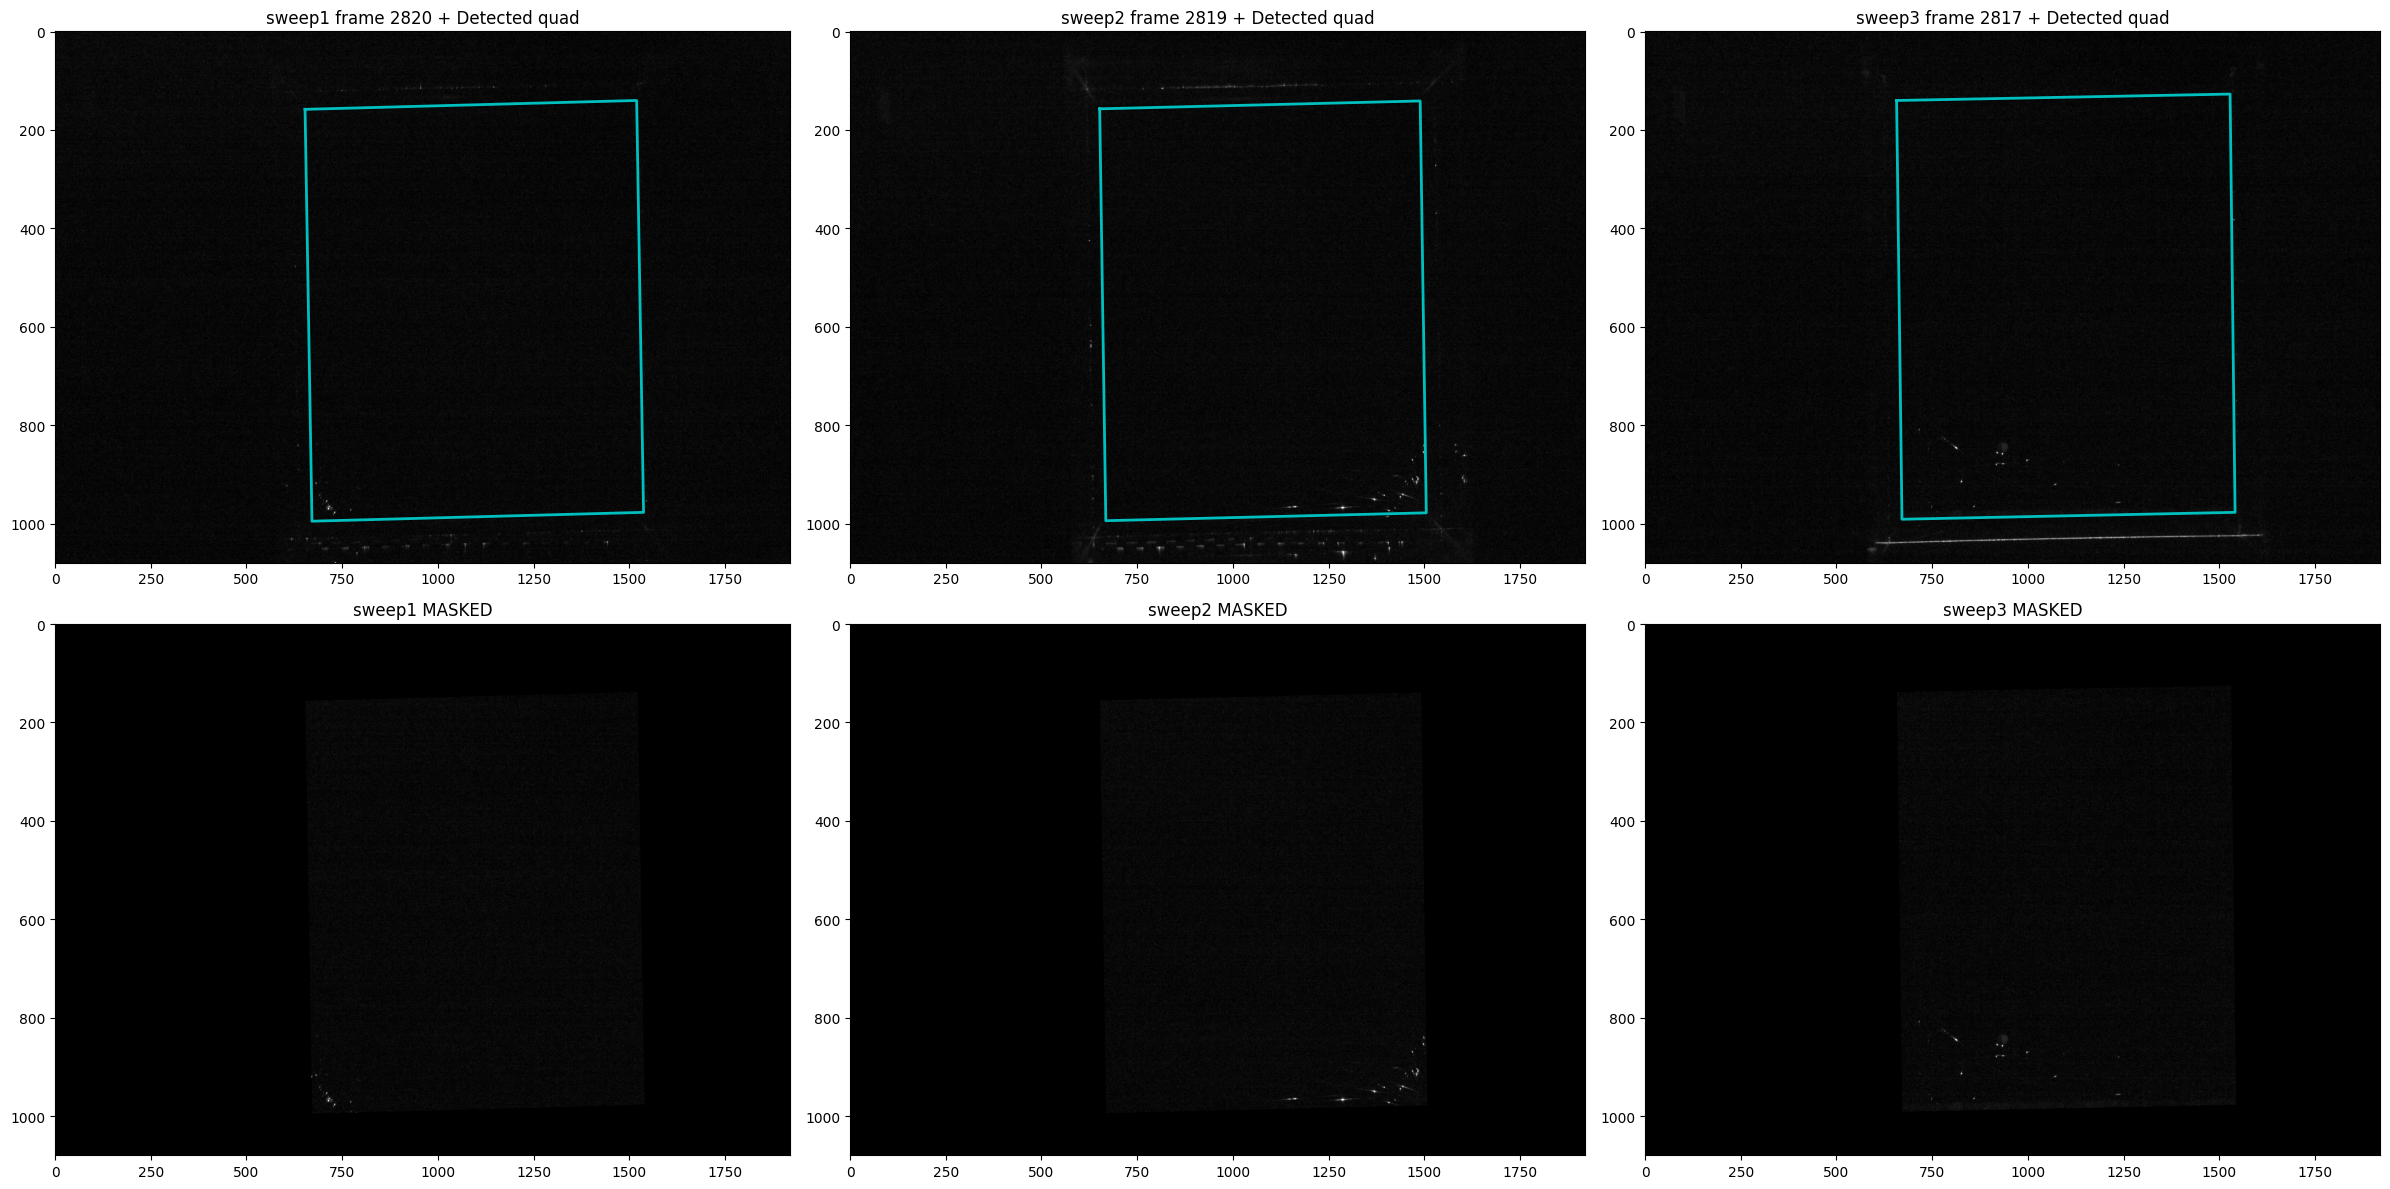

quad_vertices for pipeline:
  sweep1: [[653, 158], [1519, 140], [1537, 977], [671, 995]]
  sweep2: [[652, 157], [1489, 141], [1505, 978], [668, 994]]
  sweep3: [[657, 140], [1528, 127], [1541, 977], [671, 991]]


In [5]:
fig, axes = plt.subplots(2, len(capture_set.sweeps), figsize=(8*len(capture_set.sweeps), 12))
if len(capture_set.sweeps) == 1: axes = axes.reshape(-1, 1)
quad_vertices = {}
for sid, q in detected_quads.items():
    quad_vertices[sid] = [[int(v[0]),int(v[1])] for v in q]
for si, sweep_info in enumerate(capture_set.sweeps):
    sid = sweep_info['id']
    vid_path = os.path.join(capture_set.directory, sweep_info['video_path'])
    cap = cv2.VideoCapture(vid_path)
    mid = int(cap.get(cv2.CAP_PROP_FRAME_COUNT)) // 2
    cap.set(cv2.CAP_PROP_POS_FRAMES, mid)
    ret, frame = cap.read()
    cap.release()
    gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY).astype(np.float32)/255.0
    h_f, w_f = gray.shape
    qv = quad_vertices.get(sid)
    mask = np.zeros((h_f, w_f), dtype=np.float32)
    if qv is not None:
        poly = np.array(qv, dtype=np.int32)
        cv2.fillPoly(mask, [poly], 1.0)
        src = 'Detected quad'
    else:
        src = 'No mask'; mask[:] = 1.0
        poly = np.array([[0,0],[w_f,0],[w_f,h_f],[0,h_f]])
    masked = gray * mask
    ax = axes[0, si]
    ax.imshow(gray, cmap='gray', aspect='auto')
    pc = np.vstack([poly, poly[0:1]])
    ax.plot(pc[:,0], pc[:,1], 'c-', lw=2)
    ax.set_title(f'{sid} frame {mid} + {src}')
    ax = axes[1, si]
    ax.imshow(masked, cmap='gray', aspect='auto')
    ax.set_title(f'{sid} MASKED')
plt.tight_layout(); plt.show()
print('quad_vertices for pipeline:')
for sid, qv in quad_vertices.items(): print(f'  {sid}: {qv}')

## 3.9 Manual Override (optional)

In [ ]:
# Edit any vertices, then re-run. Example:
# quad_vertices['sweep1'] = [[500, 50], [1300, 60], [1350, 750], [450, 740]]
fig, axes = plt.subplots(1, len(capture_set.sweeps), figsize=(8*len(capture_set.sweeps), 7))
if len(capture_set.sweeps) == 1: axes = [axes]
for si, sweep_info in enumerate(capture_set.sweeps):
    ax = axes[si]; sid = sweep_info['id']
    if sid in sum_images: ax.imshow(sum_images[sid], cmap='hot', aspect='auto')
    qv = quad_vertices.get(sid)
    if qv is not None:
        qv = np.array(qv); qvc = np.vstack([qv, qv[0:1]])
        ax.plot(qvc[:,0], qvc[:,1], 'c-', lw=3, label='Quad mask')
        ax.scatter(qv[:,0], qv[:,1], c='cyan', s=100, zorder=5)
        for vi, v in enumerate(qv):
            ax.text(v[0]+10, v[1]-10, f'v{vi}({v[0]:.0f},{v[1]:.0f})', color='cyan', fontsize=8, fontweight='bold')
    ax.legend(fontsize=9)
    ax.set_title(f"{sid} - {'Quad SET' if qv is not None else 'Manifest fallback'}")
plt.tight_layout(); plt.show()


## 4. Process Sweeps & Merge

In [ ]:
def run_pipeline(config, suffix):
    processor = silkscan_proto.SweepProcessor(config)
    merger = silkscan_proto.SweepMerger(config)
    sweep_pcds = []
    print(f"\n--- Running Pipeline for {config.method} ---")
    for sweep_info in capture_set.sweeps:
        vid_path = os.path.join(capture_set.directory, sweep_info['video_path'])
        manual_quad = quad_vertices.get(sweep_info['id'])
        print(f"  {sweep_info['id']}: mask={'QUAD' if manual_quad else 'MANIFEST'}")
        pcd_data = processor.process_video(vid_path, sweep_info, capture_set.manifest,
                                           override_mask_poly=manual_quad)
        print(f"    -> {len(pcd_data)} points" if len(pcd_data) > 0 else "    -> 0 points")
        sweep_path = os.path.join(output_dir, f"{sweep_info['id']}_{suffix}.pcd")
        silkscan_proto.save_pcd(pcd_data, sweep_path)
        sweep_pcds.append(pcd_data)
    final = merger.merge_sweeps(sweep_pcds, capture_set.manifest)
    print(f'Generated {len(final)} total points for {config.method}.')
    out = os.path.join(output_dir, f'tangle016_clean_{suffix}.pcd')
    silkscan_proto.save_pcd(final, out)
    return out
path_steger = run_pipeline(config_steger, "steger")
path_thresh = run_pipeline(config_thresh, "thresh")

## 5. Visualize

In [ ]:
for sweep_info in capture_set.sweeps:
    ps = os.path.join(output_dir, f"{sweep_info['id']}_steger.pcd")
    pt = os.path.join(output_dir, f"{sweep_info['id']}_thresh.pcd")
    if os.path.exists(ps) and os.path.exists(pt):
        pcd_s = o3d.io.read_point_cloud(ps); pcd_t = o3d.io.read_point_cloud(pt)
        pcd_s.paint_uniform_color([0.2,0.2,1.0]); pcd_t.paint_uniform_color([1.0,0.2,0.2])
        pcd_t.translate((400.0,0,0))
        print(f"{sweep_info['id']}: Steger (Blue) vs Threshold (Red)")
        o3d.visualization.draw_geometries([pcd_s, pcd_t])
ps = os.path.join(output_dir, 'tangle016_clean_steger.pcd')
pt = os.path.join(output_dir, 'tangle016_clean_thresh.pcd')
if os.path.exists(ps) and os.path.exists(pt):
    pcd_s = o3d.io.read_point_cloud(ps); pcd_t = o3d.io.read_point_cloud(pt)
    pcd_s.paint_uniform_color([0.2,0.8,1.0]); pcd_t.paint_uniform_color([1.0,0.5,0.2])
    pcd_t.translate((400.0,0,0))
    print("Final Merged: Steger vs Threshold")
    o3d.visualization.draw_geometries([pcd_s, pcd_t])